---
title: "Robustness of YOLOv8 Under Image Degradations"
format:
    html: 
        code-fold: false
---

## Imports

In [13]:
import os
import glob
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Introduction and Motivation

## Degradation Pipeline

### Types of Degradations

OpenCV with randomized parameter ranges

### Implementation

In [10]:
# Set random seed
np.random.seed(297)

# Apply blur
def apply_blur(img):
    k = np.random.choice([9, 11, 15])
    return cv2.GaussianBlur(img, (k, k), 0)

# Apply noise
def apply_noise(img):
    std = np.random.uniform(25, 40)
    noise = np.random.normal(0, std, img.shape).astype(np.float32)
    out = img.astype(np.float32) + noise
    return np.clip(out, 0, 255).astype(np.uint8)

# Apply motion blur
def apply_motion(img):
    k = np.random.choice([13, 15, 17])
    kernel = np.zeros((k, k), dtype=np.float32)
    # Choose direction
    direction = np.random.choice(["horizontal", "vertical", "diag_down", "diag_up"])
    if direction == "horizontal":
        kernel[k // 2, :] = 1.0
    elif direction == "vertical":
        kernel[:, k // 2] = 1.0
    elif direction == "diag_down":
        np.fill_diagonal(kernel, 1.0)
    else:
        np.fill_diagonal(np.fliplr(kernel), 1.0)
    kernel = kernel / kernel.sum()
    return cv2.filter2D(img, -1, kernel)

# Apply mixed degradation
def apply_mixed(img):
    out = apply_blur(img)
    out = apply_noise(out)
    out = apply_motion(out)
    return out

In [11]:
# Create degraded set
def make_degraded_set(src_img_dir, src_lbl_dir, out_img_dir, out_lbl_dir, mode):
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)
    image_paths = sorted(glob.glob(os.path.join(src_img_dir, "*.jpg")))
    image_paths += sorted(glob.glob(os.path.join(src_img_dir, "*.png")))
    image_paths += sorted(glob.glob(os.path.join(src_img_dir, "*.jpeg")))

    for img_path in image_paths:
        filename = os.path.basename(img_path)
        stem = os.path.splitext(filename)[0]
        # Read image
        img = cv2.imread(img_path)
        if img is None:
            continue
        # Apply chosen degradation
        if mode == "blur":
            out = apply_blur(img)
        elif mode == "noise":
            out = apply_noise(img)
        elif mode == "motion":
            out = apply_motion(img)
        elif mode == "mixed":
            out = apply_mixed(img)
        else:
            raise ValueError("mode must be blur, noise, motion, or mixed")
        # Save degraded image
        cv2.imwrite(os.path.join(out_img_dir, filename), out)
        # Copy label
        label_src = os.path.join(src_lbl_dir, stem + ".txt")
        label_dst = os.path.join(out_lbl_dir, stem + ".txt")
        if os.path.exists(label_src):
            shutil.copy(label_src, label_dst)

In [12]:
# Set base path
base = "../data/processed/stage3_disease"

# Set source folders
src_img = os.path.join(base, "images", "test")
src_lbl = os.path.join(base, "labels", "test")

# Create blur set
make_degraded_set(
    src_img, src_lbl,
    os.path.join(base, "images", "test_blur"),
    os.path.join(base, "labels", "test_blur"),
    "blur"
)

# Create noise set
make_degraded_set(
    src_img, src_lbl,
    os.path.join(base, "images", "test_noise"),
    os.path.join(base, "labels", "test_noise"),
    "noise"
)

# Create motion set
make_degraded_set(
    src_img, src_lbl,
    os.path.join(base, "images", "test_motion"),
    os.path.join(base, "labels", "test_motion"),
    "motion"
)

# Create mixed set
make_degraded_set(
    src_img, src_lbl,
    os.path.join(base, "images", "test_mixed"),
    os.path.join(base, "labels", "test_mixed"),
    "mixed"
)

In [17]:
# Check folder counts
for folder in ["test", "test_blur", "test_noise", "test_motion", "test_mixed"]:
    img_dir = os.path.join(base, "images", folder)
    lbl_dir = os.path.join(base, "labels", folder)

    print(folder)
    print("images:", len(os.listdir(img_dir)))
    print("labels:", len(os.listdir(lbl_dir)))
    print("-" * 30)

test
images: 250
labels: 250
------------------------------
test_blur
images: 250
labels: 250
------------------------------
test_noise
images: 250
labels: 250
------------------------------
test_motion
images: 250
labels: 250
------------------------------
test_mixed
images: 250
labels: 250
------------------------------


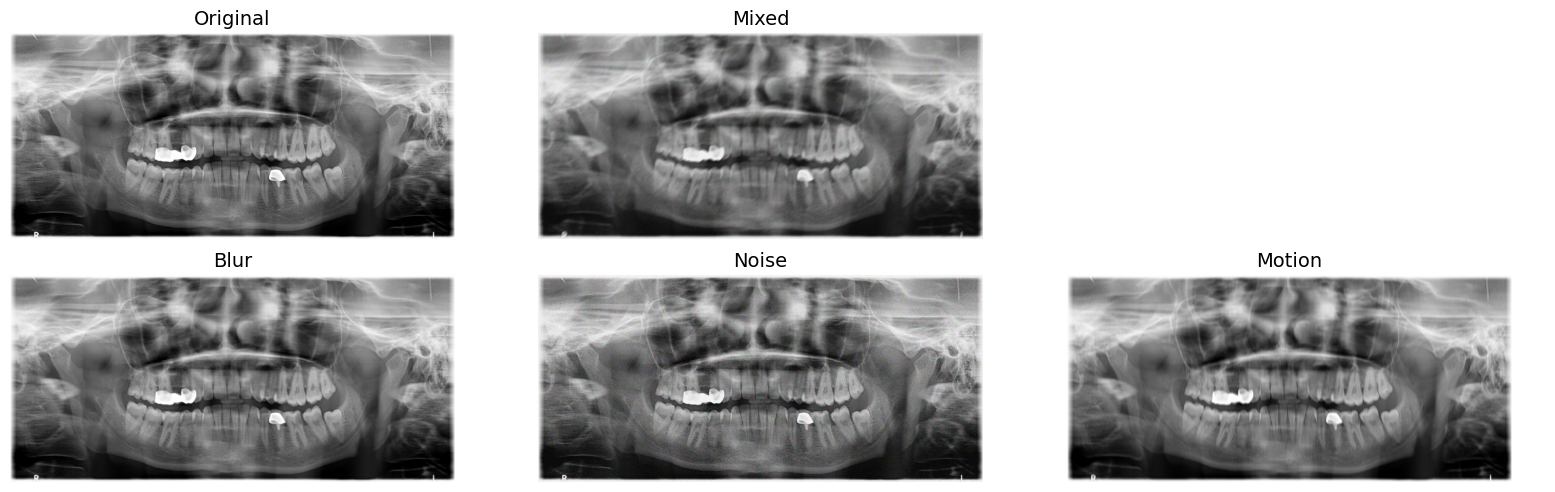

In [24]:
# Show results
img = cv2.imread("../data/processed/stage3_disease/images/test/test_0.png")
plt.figure(figsize=(16, 5))  

# Original
plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original", fontsize=14)
plt.axis("off")

# Mixed
plt.subplot(2,3,2)
plt.imshow(cv2.cvtColor(apply_mixed(img), cv2.COLOR_BGR2RGB))
plt.title("Mixed", fontsize=14)
plt.axis("off")

# Empty space 
plt.subplot(2,3,3)
plt.axis("off")

# Blur
plt.subplot(2,3,4)
plt.imshow(cv2.cvtColor(apply_blur(img), cv2.COLOR_BGR2RGB))
plt.title("Blur", fontsize=14)
plt.axis("off")

# Noise
plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(apply_noise(img), cv2.COLOR_BGR2RGB))
plt.title("Noise", fontsize=14)
plt.axis("off")

# Motion
plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(apply_motion(img), cv2.COLOR_BGR2RGB))
plt.title("Motion", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.show()

## Experimental Setup